# YouTube trending — like-ok számának predikciója Random Foresttel

**Feladat:** megjósolni, hogy egy új YouTube videó hány like-ot fog kapni, *feltöltés előtti* információk alapján (cím, tag-ek, kategória, publikálás időpontja stb.).

**Miért csak ezek?** Mert ha olyan feature-öket használnánk, mint a `views`, `comment_count`, `dislikes`, az **data leakage** lenne: ezek a videó életéből keletkeznek, nem ismertek feltöltéskor. Ha bevennénk őket, a modell gyanúsan jó (R² ~0.88) lenne — de hamis módon, mert a modell lényegében a like/view arányt "tanulná meg", ami a legtöbb csatornán nagyjából konstans.

**Realisztikus várható eredmény:** R² kb. 0.2–0.4. Ez tűnik alacsonynak, de őszinte eredmény — egy videó sikerét nehéz előre megmondani pusztán metaadatokból.

In [11]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("datasnaek/youtube-new")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\pocsa\.cache\kagglehub\datasets\datasnaek\youtube-new\versions\115


## 1. Adat beolvasása

In [12]:
import pandas as pd
import numpy as np
import os

# Útvonal a Google Drive-ban
path = "C:\\Users\\pocsa\\.cache\\kagglehub\\datasets\\datasnaek\\youtube-new\\versions\\115"
filepath_gbvideos = os.path.join(path, "GBvideos.csv")

df = pd.read_csv(filepath_gbvideos)
print(f"Beolvasva: {len(df)} sor, {df.shape[1]} oszlop")
df.head()

Beolvasva: 38916 sor, 16 oszlop


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,Jw1Y-zhQURU,17.14.11,John Lewis Christmas Ad 2017 - #MozTheMonster,John Lewis,26,2017-11-10T07:38:29.000Z,"christmas|""john lewis christmas""|""john lewis""|...",7224515,55681,10247,9479,https://i.ytimg.com/vi/Jw1Y-zhQURU/default.jpg,False,False,False,Click here to continue the story and make your...
1,3s1rvMFUweQ,17.14.11,Taylor Swift: …Ready for It? (Live) - SNL,Saturday Night Live,24,2017-11-12T06:24:44.000Z,"SNL|""Saturday Night Live""|""SNL Season 43""|""Epi...",1053632,25561,2294,2757,https://i.ytimg.com/vi/3s1rvMFUweQ/default.jpg,False,False,False,Musical guest Taylor Swift performs …Ready for...
2,n1WpP7iowLc,17.14.11,Eminem - Walk On Water (Audio) ft. Beyoncé,EminemVEVO,10,2017-11-10T17:00:03.000Z,"Eminem|""Walk""|""On""|""Water""|""Aftermath/Shady/In...",17158579,787420,43420,125882,https://i.ytimg.com/vi/n1WpP7iowLc/default.jpg,False,False,False,Eminem's new track Walk on Water ft. Beyoncé i...
3,PUTEiSjKwJU,17.14.11,Goals from Salford City vs Class of 92 and Fri...,Salford City Football Club,17,2017-11-13T02:30:38.000Z,"Salford City FC|""Salford City""|""Salford""|""Clas...",27833,193,12,37,https://i.ytimg.com/vi/PUTEiSjKwJU/default.jpg,False,False,False,Salford drew 4-4 against the Class of 92 and F...
4,rHwDegptbI4,17.14.11,Dashcam captures truck's near miss with child ...,Cute Girl Videos,25,2017-11-13T01:45:13.000Z,[none],9815,30,2,30,https://i.ytimg.com/vi/rHwDegptbI4/default.jpg,False,False,False,Dashcam captures truck's near miss with child ...


## 2. Adattisztítás

**Fontos: deduplikáció videó szinten.**
A datasetben minden videó annyiszor szerepel, ahány napig trendelt. Ha ezt nem kezeljük, ugyanaz a videó lehet a train és a test setben is, ami hamisan megemeli a pontosságot. Ezért videónként csak **egy** sort tartunk meg: az *utolsó* trending dátumit, mert az tükrözi a végleges like-számot.

In [13]:
# --- Dátumok típuskonverziója ---
# A trending_date formátum '17.14.11' = YY.DD.MM
df["trending_date"] = pd.to_datetime(df["trending_date"], format="%y.%d.%m")
# A publish_time ISO string időzónával, ezt levágjuk, hogy tiszta datetime legyen
df["publish_time"] = pd.to_datetime(df["publish_time"]).dt.tz_localize(None)

# --- Deduplikáció: videónként az utolsó trending nap marad ---
# Rendezzük trending_date szerint, majd video_id alapján csoportosítva az utolsót vesszük
df = df.sort_values("trending_date").groupby("video_id", as_index=False).last()
print(f"Deduplikáció után: {len(df)} egyedi videó")

# --- Bool oszlopok int-té ---
# A sklearn modellek numerikus inputot várnak, True/False helyett 1/0
bool_cols = ["comments_disabled", "ratings_disabled", "video_error_or_removed"]
df[bool_cols] = df[bool_cols].astype(int)

# --- Eldobjuk a törölt vagy hibás videókat (ritkaság, de zavaró) ---
df = df[df["video_error_or_removed"] == 0].copy()

df.info()

Deduplikáció után: 3272 egyedi videó
<class 'pandas.DataFrame'>
Index: 3267 entries, 0 to 3271
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   video_id                3267 non-null   str           
 1   trending_date           3267 non-null   datetime64[us]
 2   title                   3267 non-null   str           
 3   channel_title           3267 non-null   str           
 4   category_id             3267 non-null   int64         
 5   publish_time            3267 non-null   datetime64[us]
 6   tags                    3267 non-null   str           
 7   views                   3267 non-null   int64         
 8   likes                   3267 non-null   int64         
 9   dislikes                3267 non-null   int64         
 10  comment_count           3267 non-null   int64         
 11  thumbnail_link          3267 non-null   str           
 12  comments_disabled       326

## 3. Feature engineering

Csak olyan feature-öket készítünk, amik **feltöltés előtt / feltöltés pillanatában** ismertek:
- `category_id` — kategória (Music=10, Gaming=20 stb.)
- `publish_*` — mikor töltötte fel (hónap, hét napja, óra, hétvége-e)
- `title_*` — címből kivonható jellemzők (hossz, szószám, nagybetűs szavak aránya, felkiáltó/kérdőjel, szám-e benne)
- `tag_count` — tag-ek száma
- `desc_length` — leírás hossza
- `comments_disabled`, `ratings_disabled` — beállítások

**Kimarad szándékosan:** `views`, `dislikes`, `comment_count`, `days_to_trend`, `like_rate`, `engagement_rate` stb. — ezek mind a videó élete során keletkeznek, nem jósolhatók előre.

In [14]:
# --- Publikálási időpont feature-ök ---
df["publish_month"]      = df["publish_time"].dt.month          # 1-12
df["publish_dayofweek"]  = df["publish_time"].dt.dayofweek      # 0=hétfő, 6=vasárnap
df["publish_hour"]       = df["publish_time"].dt.hour           # 0-23
df["publish_is_weekend"] = df["publish_dayofweek"].isin([5, 6]).astype(int)

# --- Cím feature-ök ---
df["title_length"]     = df["title"].str.len()
df["title_word_count"] = df["title"].str.split().str.len()
# Milyen arányban van teljesen nagybetűs szó a címben? (pl. "OFFICIAL", "NEW") - clickbait indikátor
df["title_caps_ratio"] = df["title"].apply(
    lambda x: sum(1 for w in str(x).split() if w.isupper()) / (len(str(x).split()) + 1)
)
df["title_exclamation"] = df["title"].str.count("!")
df["title_question"]    = df["title"].str.count(r"\?")
df["title_has_number"]  = df["title"].str.contains(r"\d").astype(int)

# --- Tag feature-ök ---
# A tag-ek '|' karakterrel vannak elválasztva, '[none]' = nincs tag
df["tag_count"] = df["tags"].apply(
    lambda x: 0 if x == "[none]" else len(str(x).split("|"))
)

# --- Leírás feature ---
df["desc_length"] = df["description"].str.len().fillna(0)

print("Feature engineering kész.")
df[["title", "title_length", "title_caps_ratio", "title_exclamation", "tag_count", "desc_length"]].head()

Feature engineering kész.


,title,title_length,title_caps_ratio,title_exclamation,tag_count,desc_length
0,Paul McCartney - Pipes of Peace,31,0.000000,0,5,31.0
1,NEW YEAR'S EVE MAKEUP TUTORIAL | JAMIE GENEVIEVE,48,0.777778,0,13,4233.0
2,RAMPAGE - OFFICIAL TRAILER 2 [HD],33,0.571429,0,29,2952.0
3,Neymar will win the Ballon d'Or | Philippe Cou...,70,0.000000,0,30,609.0
4,Havana - swing cover | dodie feat. FLASHBACK,44,0.111111,0,8,751.0


## 4. Target (célváltozó) és feature-lista

**Log-transzformáció a targeten:** a like-ok eloszlása erősen jobbra ferde — a legtöbb videó pár ezer like-ot kap, de néhány milliós. Ha log-transzformáljuk (`log1p(x) = log(1+x)`), az eloszlás közelít a normálishoz, és a modell sokkal jobban teljesít, mert nem dominálnak a kiugró értékek.

In [15]:
# --- Feature-ök listája (csak olyanok, amik feltöltéskor ismertek!) ---
features = [
    "category_id",
    "publish_month", "publish_dayofweek", "publish_hour", "publish_is_weekend",
    "title_length", "title_word_count", "title_caps_ratio",
    "title_exclamation", "title_question", "title_has_number",
    "tag_count", "desc_length",
    "comments_disabled", "ratings_disabled",
]

X = df[features].copy()
y = df["likes"].copy()

# Log-transzformáció a targeten: log(1+x), így a 0 like is kezelhető
y_log = np.log1p(y)

print(f"X shape: {X.shape}")
print(f"y eredeti skála: min={y.min()}, max={y.max()}, medián={y.median():.0f}")
print(f"y log skála:    min={y_log.min():.2f}, max={y_log.max():.2f}")

X shape: (3267, 15)
y eredeti skála: min=0, max=5613827, medián=13379
y log skála:    min=0.00, max=15.54


## 5. Train/test split

In [16]:
from sklearn.model_selection import train_test_split

# 80% tanítás, 20% teszt. A random_state rögzítésével reprodukálható a felbontás.
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

# Tároljuk a test eredeti (nem-log) like-okat is a kiértékeléshez
y_test_orig = np.expm1(y_test_log)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Train: 2613, Test: 654


## 6. Random Forest modell

**Hiperparaméterek magyarázata:**
- `n_estimators=300` — 300 döntési fát tanítunk, átlagolunk. Több fa = stabilabb, de lassabb.
- `max_depth=None` — a fák nőhetnek ameddig akarnak (a `min_samples_leaf` szab gátat).
- `min_samples_leaf=5` — egy levélben legalább 5 minta legyen. Ez **védelem az overfitting ellen**: ha minden levél csak 1 mintát tartalmazna, a modell memorizálná a tanító halmazt.
- `max_features="sqrt"` — minden split-nél csak √(feature-szám) feature-t nézünk. Ez a Random Forest **titka**: így a fák különböznek egymástól, az átlag robusztusabb.
- `n_jobs=-1` — használja az összes CPU magot párhuzamosan.

In [17]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=5,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42,
)

# Tanítás log-transzformált targeten
rf_model.fit(X_train, y_train_log)
print("Random Forest modell betanítva.")

Random Forest modell betanítva.


## 7. Kiértékelés

Regressziós metrikákat használunk (NEM accuracy/F1/ROC-AUC — azok osztályozáshoz valók):
- **R²** — a variancia hány részét magyarázza a modell (0–1 közt, 1 = tökéletes)
- **RMSE** — átlagos négyzetes hiba gyöke, like-okban
- **MAE** — átlagos abszolút hiba, like-okban (intuitív: átlagosan ennyivel tévedünk)

In [18]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Predikció log-skálán
y_pred_log = rf_model.predict(X_test)
# Visszatranszformálás eredeti skálára
y_pred = np.expm1(y_pred_log)

# R²-t log-skálán nézzük (mivel a modell ezen tanult)
r2_log = r2_score(y_test_log, y_pred_log)
# RMSE és MAE eredeti like-skálán, hogy értelmezhető legyen
rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred))
mae  = mean_absolute_error(y_test_orig, y_pred)

print(f"R² (log skálán):  {r2_log:.4f}")
print(f"RMSE (like):      {rmse:,.0f}")
print(f"MAE (like):       {mae:,.0f}")
print(f"Medián valós like: {y_test_orig.median():,.0f}")

R² (log skálán):  0.3616
RMSE (like):      296,049
MAE (like):       88,428
Medián valós like: 13,093


### Feature importance — mi számít a leginkább?

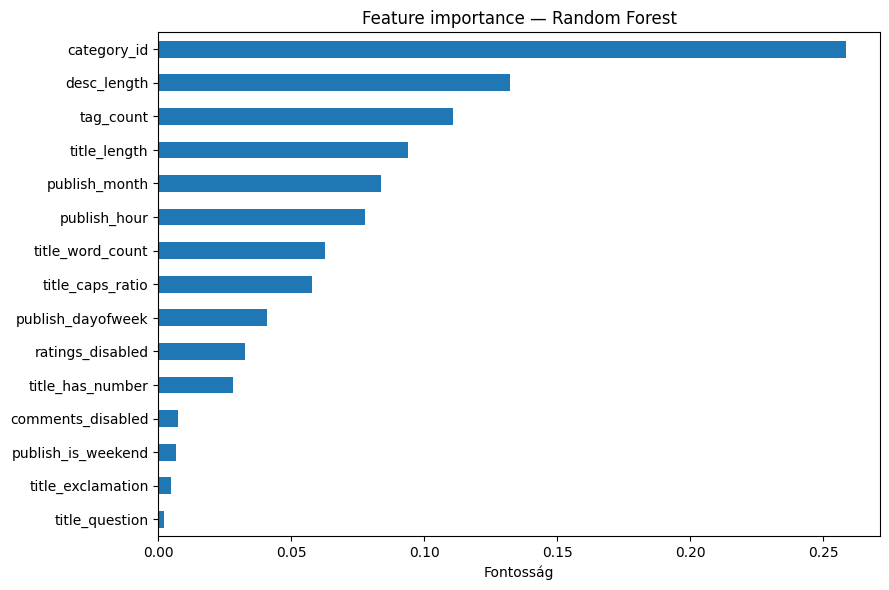

category_id           0.258412
desc_length           0.132280
tag_count             0.110821
title_length          0.093954
publish_month         0.083558
publish_hour          0.077665
title_word_count      0.062525
title_caps_ratio      0.057929
publish_dayofweek     0.040670
ratings_disabled      0.032671
title_has_number      0.028021
comments_disabled     0.007507
publish_is_weekend    0.006773
title_exclamation     0.004930
title_question        0.002284
dtype: float64


In [19]:
import matplotlib.pyplot as plt

# A RF-ben minden feature kap egy fontossági pontszámot: mennyit csökkentett a hibát az adott feature-rel történő splitelés
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values()

plt.figure(figsize=(9, 6))
importances.plot(kind="barh")
plt.title("Feature importance — Random Forest")
plt.xlabel("Fontosság")
plt.tight_layout()
plt.show()

print(importances.sort_values(ascending=False))

## 8. Új videó tesztelése

Ez a lényeg: a modellt úgy kell használni, hogy egy **nyers új videó** (cím, tag-ek, időpont, kategória) alapján pontosan azokat a feature-öket számoljuk ki, amiket a modell látott tanításkor. Csinálok erre egy segédfüggvényt, hogy ne lehessen véletlenül eltérő feature-öket gyártani.

In [20]:
def prepare_new_video(title, tags, description, publish_time,
                      category_id, comments_disabled=0, ratings_disabled=0):
    """
    Egy új videó nyers adataiból előállítja pontosan azt a feature-sort,
    amit a Random Forest modell vár. Ugyanazt a logikát használja,
    mint a tanító adatok feature engineeringje.

    Paraméterek:
        title (str): a videó címe
        tags (str): '|' elválasztott tag-ek, vagy '[none]'
        description (str): a videó leírása ('' ha nincs)
        publish_time (str): ISO dátum (pl. '2024-11-15T18:30:00')
        category_id (int): YouTube kategória ID (pl. 10=Music, 20=Gaming, 24=Entertainment)
        comments_disabled (int): 0 vagy 1
        ratings_disabled (int): 0 vagy 1
    """
    pt = pd.Timestamp(publish_time)

    row = {
        "category_id":         category_id,
        "publish_month":       pt.month,
        "publish_dayofweek":   pt.dayofweek,
        "publish_hour":        pt.hour,
        "publish_is_weekend":  int(pt.dayofweek in [5, 6]),
        "title_length":        len(title),
        "title_word_count":    len(title.split()),
        "title_caps_ratio":    sum(1 for w in title.split() if w.isupper()) / (len(title.split()) + 1),
        "title_exclamation":   title.count("!"),
        "title_question":      title.count("?"),
        "title_has_number":    int(any(c.isdigit() for c in title)),
        "tag_count":           0 if tags == "[none]" else len(tags.split("|")),
        "desc_length":         len(description) if description else 0,
        "comments_disabled":   comments_disabled,
        "ratings_disabled":    ratings_disabled,
    }
    # Ugyanaz az oszlopsorrend, mint a tanításnál!
    return pd.DataFrame([row])[features]


# --- Teszteljünk egy új videót ---
new_video = prepare_new_video(
    title="My NEW Amazing Tutorial 2024!",
    tags="tutorial|coding|python|beginner",
    description="In this video I show you how to build something cool. Links below!",
    publish_time="2024-11-15T18:30:00",   # szombat este
    category_id=28,                         # Science & Technology
    comments_disabled=0,
    ratings_disabled=0,
)

print("Új videó feature-ei:")
print(new_video.T)

# Predikció log-skálán, majd visszatranszformálás
pred_log   = rf_model.predict(new_video)[0]
pred_likes = np.expm1(pred_log)

print(f"\nBecsült like-ok száma: {int(pred_likes):,}")

Új videó feature-ei:
                            0
category_id         28.000000
publish_month       11.000000
publish_dayofweek    4.000000
publish_hour        18.000000
publish_is_weekend   0.000000
title_length        29.000000
title_word_count     5.000000
title_caps_ratio     0.166667
title_exclamation    1.000000
title_question       0.000000
title_has_number     1.000000
tag_count            4.000000
desc_length         66.000000
comments_disabled    0.000000
ratings_disabled     0.000000

Becsült like-ok száma: 4,551


### Érzékenységvizsgálat — mit változtatna a címen?

Nézzük meg, hogyan változik a becslés, ha ugyanaz a videó, de más feature-ekkel:

In [21]:
variants = [
    ("alap eset",              "My Amazing Tutorial", "tutorial|coding", 28, "2024-11-15T18:30:00"),
    ("Music kategória",        "My Amazing Tutorial", "tutorial|coding", 10, "2024-11-15T18:30:00"),
    ("CLICKBAIT CÍM!!!",       "YOU WON'T BELIEVE THIS!!!", "tutorial|coding", 28, "2024-11-15T18:30:00"),
    ("hétvége",                "My Amazing Tutorial", "tutorial|coding", 28, "2024-11-16T18:30:00"),
    ("sok tag",                "My Amazing Tutorial", "|".join([f"tag{i}" for i in range(20)]), 28, "2024-11-15T18:30:00"),
]

for name, title, tags, cat, pt in variants:
    v = prepare_new_video(title, tags, "desc", pt, cat)
    pred = np.expm1(rf_model.predict(v)[0])
    print(f"{name:20s} -> {int(pred):>8,} like")

alap eset            ->    2,822 like
Music kategória      ->    5,371 like
CLICKBAIT CÍM!!!     ->    3,380 like
hétvége              ->    2,404 like
sok tag              ->    8,478 like


## 9. Összefoglalás

**Mit csináltunk:**
1. Beolvastuk a GBvideos.csv-t.
2. Deduplikáltunk videó-szinten (data leakage elkerülése!).
3. Feature engineering: *csak* feltöltés előtt ismert jellemzőkből (cím, tag, kategória, időpont).
4. Log-transzformáltuk a targetet a ferde eloszlás miatt.
5. 80/20 train/test split.
6. Random Forest Regressor 300 fával, `min_samples_leaf=5`-tel overfitting ellen.
7. Kiértékelés R²-rel, RMSE-vel, MAE-vel és feature importance-szal.
8. Új videó teszteléséhez segédfüggvényt készítettünk.

**Lehetséges következő lépések:**
- Hiperparaméter hangolás `GridSearchCV`-vel vagy `RandomizedSearchCV`-vel
- Cross-validation az R² stabilabb becsléséhez
- Összehasonlítás **Linear Regression baseline**-nel és **Gradient Boosting** (XGBoost/LightGBM) modellel
- Szöveges feature-ök TF-IDF-fel a címből
- Több ország datasetjének kombinálása (USvideos, DEvideos stb.)